<a href="https://colab.research.google.com/github/Astrages4/ML_labs/blob/main/lab1/task1_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №1
Цель: Обучить модель линейной регрессии для предсказания CGPA и логистическую регрессию для предсказания депрессии

In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Считаем датасет:

In [52]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
df = pd.read_csv("/content/drive/MyDrive/table1.csv")
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


## Разведочный анализ (EDA)

### Проверка типов данных
Проверим типы данных всех столбцов:

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB


Никакое число не записано как строка, возраста не указаны в виде дроби и оценка уровня стресса была целыми числами.
Типы данных везде соответствуют содержимому.

### Некорректные данные
Проверим, есть ли строки с некорректными данными (например, отрицательный возраст или значение CGPA больше 4.0). Посмотрим минимальное и максимальное значения по каждому столбцу:

In [55]:
df.describe()

,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,51000.500000,21.009010,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660
std,28867.657797,2.000382,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151
min,1001.000000,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,26000.750000,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,51000.500000,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,76000.250000,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,101000.000000,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


Видим, что все значения лежат в верных даипазонах.

Также проверим, есть ли строки, в которых сумма часов на сон + учебу + соц.сети, превышает 24 часа:

In [56]:
print('Количество строк до удаления некорректных значений:', df.shape[0])
cond_valid_sum_hours = (df['Sleep_Duration'] + df['Study_Hours'] + df['Social_Media_Hours']) <= 24
df = df[cond_valid_sum_hours]
print('Количество строк после удаления некорректных значений:', df.shape[0])

Количество строк до удаления некорректных значений: 100000
Количество строк после удаления некорректных значений: 99921


### Дубликаты
Удалим дубликаты, ведь могут быть записи об одних и тех же людях (совпадающий ID):

In [57]:
print(f'Количество строк в датасете до удаления дубликатов: {df.shape[0]}')
df.drop_duplicates(inplace=True)
print(f'После: {df.shape[0]}')

Количество строк в датасете до удаления дубликатов: 99921
После: 99921


Изменений нет, значит дубликатов нет

### Отбор признаков

Определим, какие признаки оставить, а какие можно убрать.
ID не нужен, он ни на что не влияет.

In [58]:
df.drop(columns=['Student_ID'], inplace=True)
df.head()

,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


#### Визуализация данных
Теперь сделаем визуализацию наших данных. Это даст нам хорошее представление о том, с чем мы вообще работаем, и поможет понять размер набора данных, их распределение, наличие пропусков, дубликатов и аномалий.

Cначала сделаем визуализации для непрерывных числовых признаков. Age и Stress_Level - это дискретные величины, их отдельно визуализируем чуть позже.

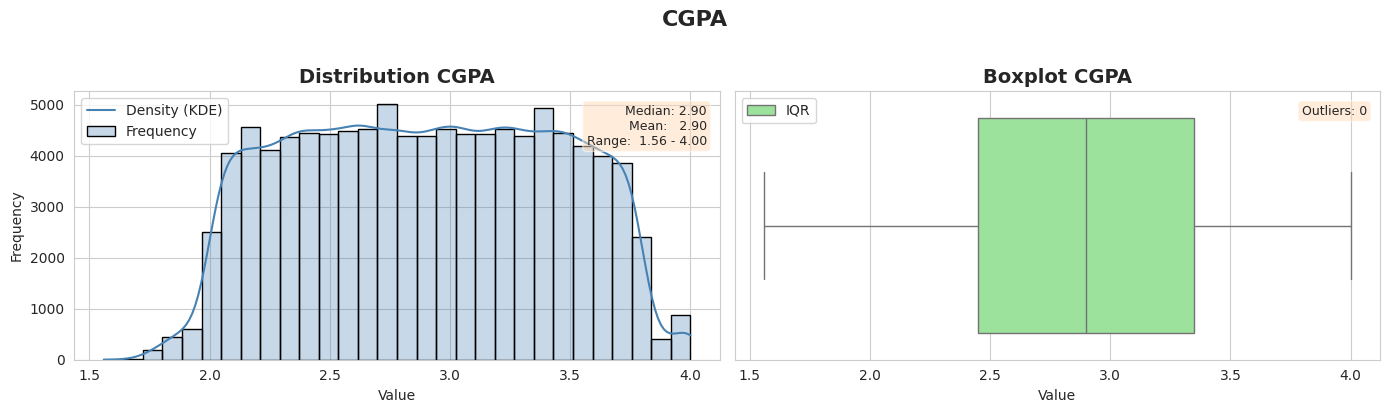

CGPA:
Пропусков: 0
Выбросов: 0


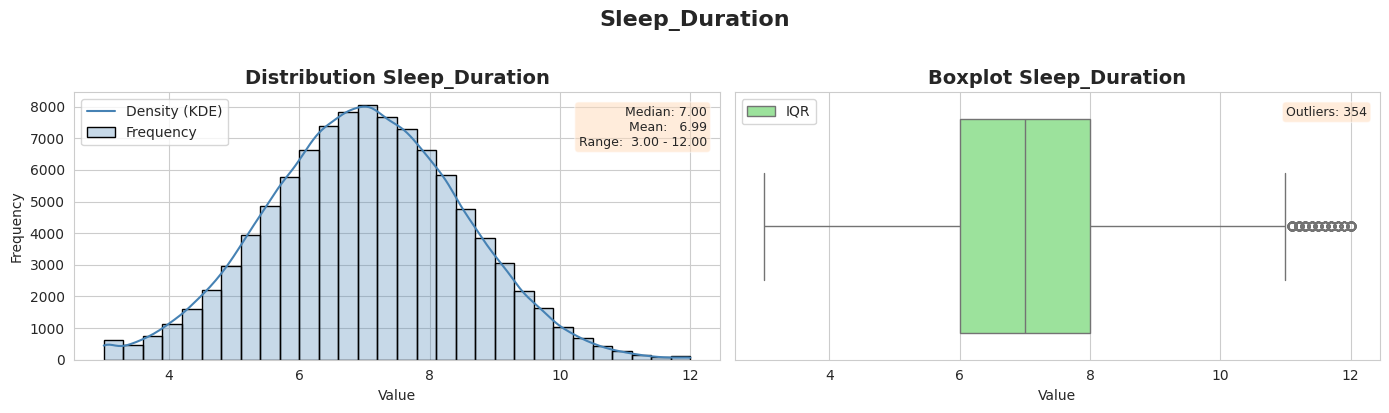

Sleep_Duration:
Пропусков: 0
Выбросов: 354


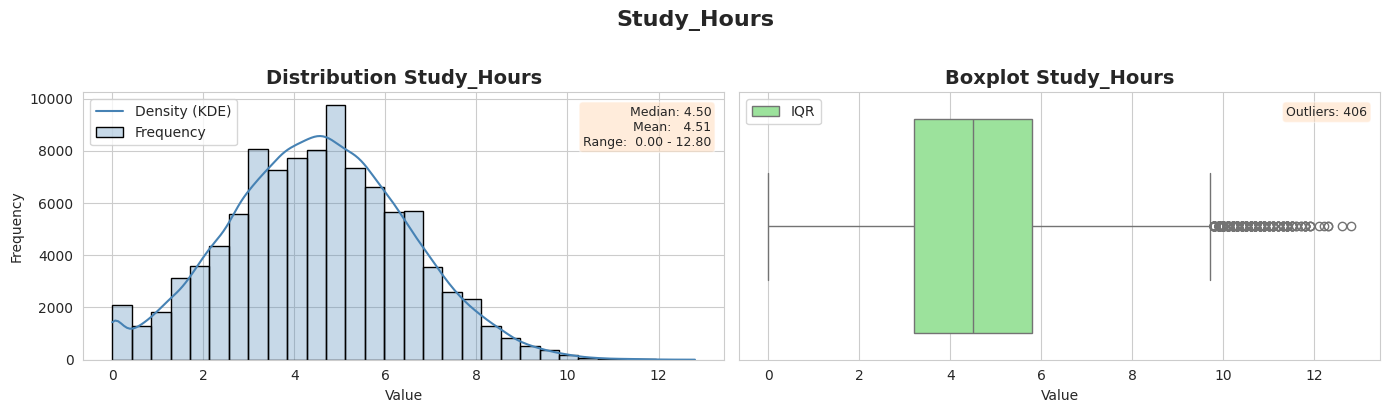

Study_Hours:
Пропусков: 0
Выбросов: 406


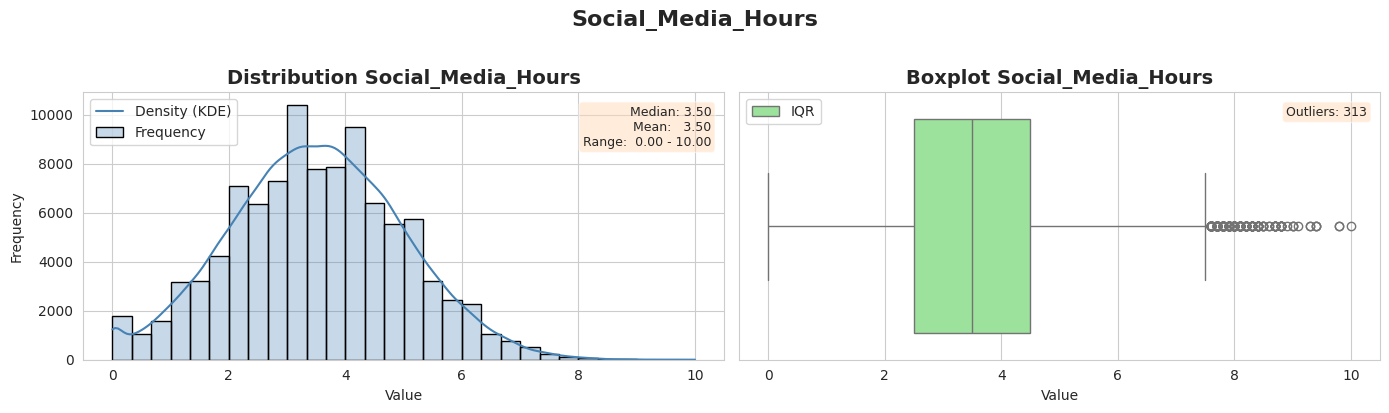

Social_Media_Hours:
Пропусков: 0
Выбросов: 313


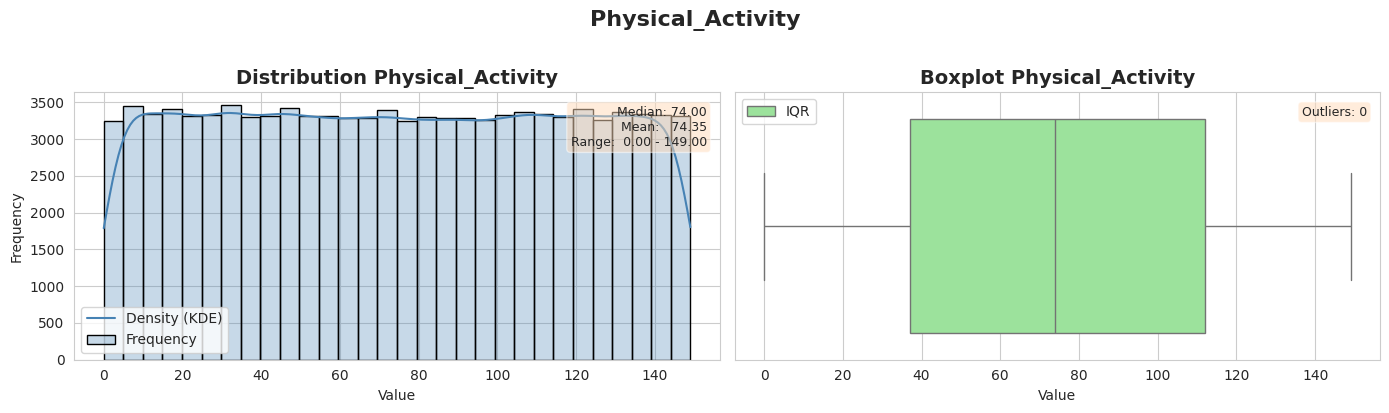

Physical_Activity:
Пропусков: 0
Выбросов: 0


In [59]:
numeric_cols = df.drop(columns=['Age', 'Stress_Level']).select_dtypes(include='number').columns.tolist()

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.set_style("whitegrid")

    # гистограмма с KDE
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[0],
                    color='steelblue', edgecolor='black', alpha=0.3)
    axes[0].set_title(f'Distribution {col}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Frequency')
    axes[0].legend(['Density (KDE)', 'Frequency'], loc='best')

    # Boxplot (ящик с усами)
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Boxplot {col}', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Value')
    axes[1].legend(['IQR', 'Медиана', 'Выбросы'], loc='best')

    # метрики для гистограммы
    stats_text_hist = (f"Median: {df[col].median():.2f}\n"
                    f"Mean:   {df[col].mean():.2f}\n"
                    f"Range:  {df[col].min():.2f} - {df[col].max():.2f}")

    axes[0].text(0.98, 0.95, stats_text_hist, transform=axes[0].transAxes,
                    fontsize=9, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))

    # считаем выбросы для Boxplot
    col_data = df[col].dropna()

    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((col_data < lower_bound) | (col_data > upper_bound)).sum()
    missing = df[col].isnull().sum()

    # метрика
    stats_text_bxp = (f"Outliers: {outliers}")

    axes[1].text(0.98, 0.95, stats_text_bxp, transform=axes[1].transAxes,
                    fontsize=9, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))

    plt.suptitle(col, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"{col}:")
    print(f"Пропусков: {missing}")
    print(f"Выбросов: {outliers}")

У параметров Age и Stress_Level мало уникальных значений (т.к. это целые числа в очень ограниченном диапазоне), поэтому для них сделаем графики с count plot вместо обычной гистограммы и pie chart для большей наглядности распределения:

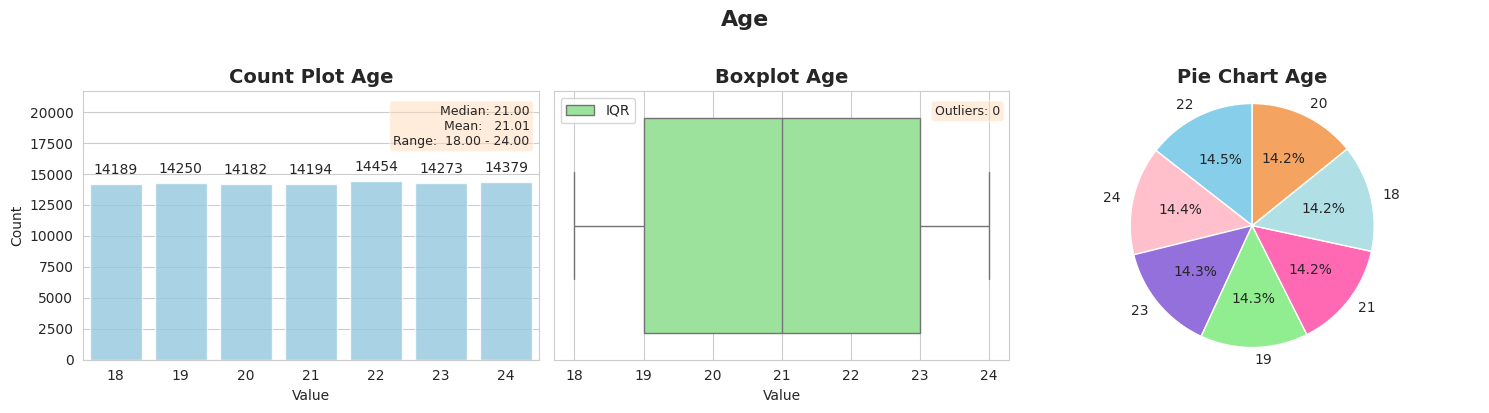

Age:
Пропусков: 0
Выбросов: 0
 18: 14.2002 %
 19: 14.2613 %
 20: 14.1932 %
 21: 14.2052 %
 22: 14.4654 %
 23: 14.2843 %
 24: 14.3904 %


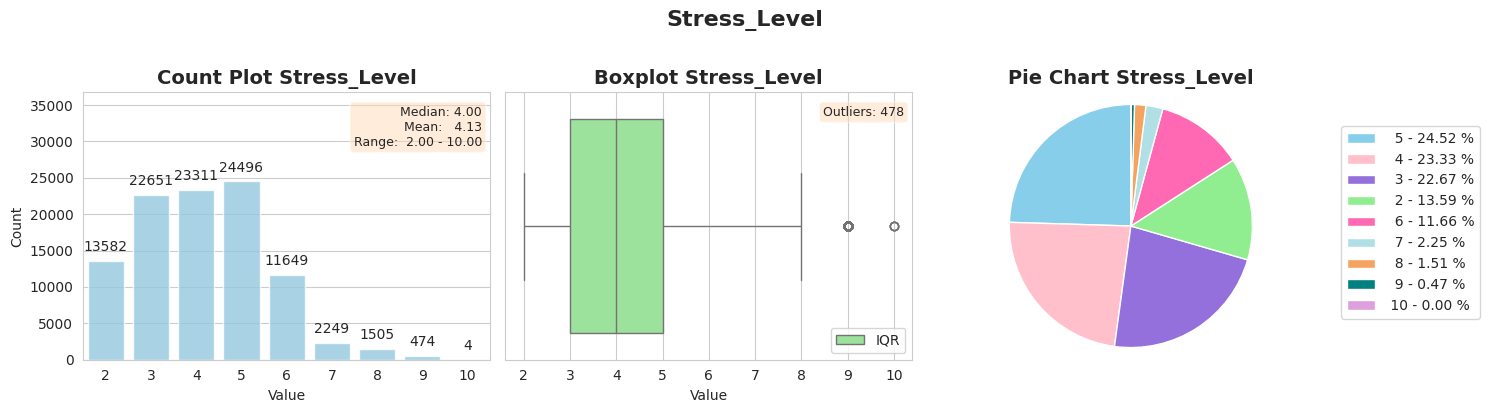

Stress_Level:
Пропусков: 0
Выбросов: 478
  2: 13.5927 %
  3: 22.6689 %
  4: 23.3294 %
  5: 24.5154 %
  6: 11.6582 %
  7: 2.2508 %
  8: 1.5062 %
  9: 0.4744 %
 10: 0.0040 %


In [60]:
for col in ('Age', 'Stress_Level'):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    sns.set_style("whitegrid")
    counted_data = df[col].value_counts()

    # count plot
    sns.countplot(data=df, x=col, ax=axes[0], color='skyblue', alpha=0.8)
    axes[0].set_title(f'Count Plot {col}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Count')
    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 10),
                    textcoords='offset points')
    axes[0].set_ylim(bottom=0, top=1.5*counted_data.values.max())

    # Boxplot (ящик с усами)
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Boxplot {col}', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Value')
    axes[1].legend(['IQR', 'Медиана', 'Выбросы'], loc='best')

    # метрики для гистограммы
    stats_text_hist = (f"Median: {df[col].median():.2f}\n"
                       f"Mean:   {df[col].mean():.2f}\n"
                       f"Range:  {df[col].min():.2f} - {df[col].max():.2f}")

    axes[0].text(0.98, 0.95, stats_text_hist, transform=axes[0].transAxes,fontsize=9,
                 verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))

    # считаем выбросы
    col_data = df[col].dropna()

    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((col_data < lower_bound) | (col_data > upper_bound)).sum()
    missing = df[col].isnull().sum()

    # метрика
    stats_text_bxp = (f"Outliers: {outliers}")

    axes[1].text(0.98, 0.95, stats_text_bxp, transform=axes[1].transAxes,
                 fontsize=9, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))

    # pie chart
    autopct = '%1.1f%%' if len(counted_data) <= 7 else None
    labels = counted_data.index if len(counted_data) <= 7 else None
    colors = ['skyblue', 'pink', 'mediumpurple', 'lightgreen', 'hotpink', 'powderblue', 'sandybrown', 'teal', 'plum']
    axes[2].pie(counted_data.values, labels=labels,
    colors=colors, autopct=autopct, startangle=90)
    axes[2].axis('equal')
    legend_data = [f'{name:3} - {(amount / counted_data.values.sum() * 100):1.2f} %' for name, amount in zip(counted_data.index, counted_data.values)]
    if not autopct:
        plt.legend(legend_data, bbox_to_anchor=(1, 0.9) , loc='best')
    axes[2].set_title(f'Pie Chart {col}', fontsize=14, fontweight='bold')

    plt.suptitle(col, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"{col}:")
    print(f"Пропусков: {missing}")
    print(f"Выбросов: {outliers}")
    print(*sorted([f'{name:3}: {(amount / counted_data.values.sum() * 100):2.4f} %' for name, amount in zip(counted_data.index, counted_data.values)]), sep='\n')

И для категориальных признаков сделаем bar plot и pie chart:

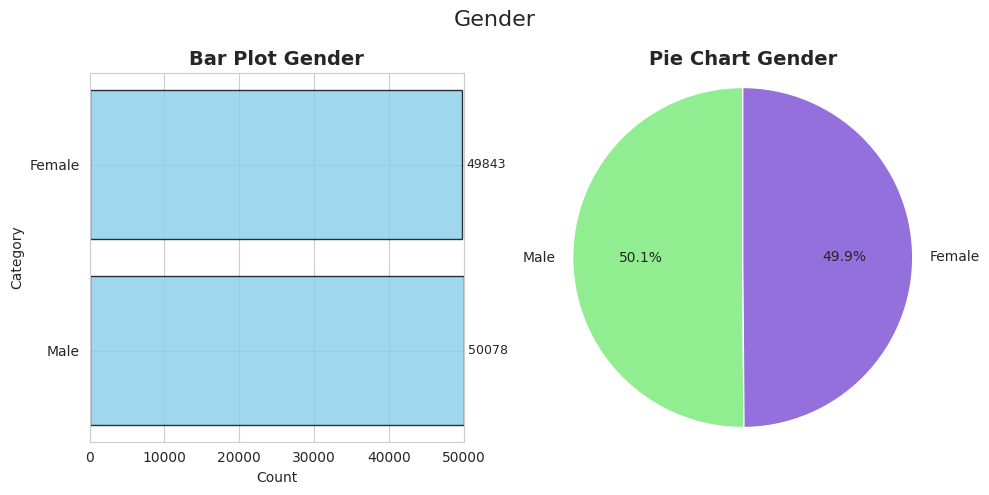

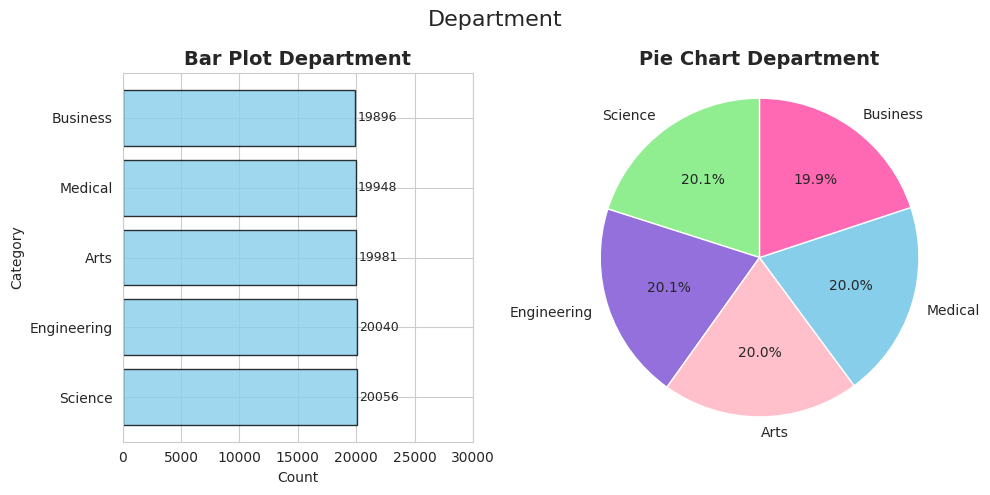

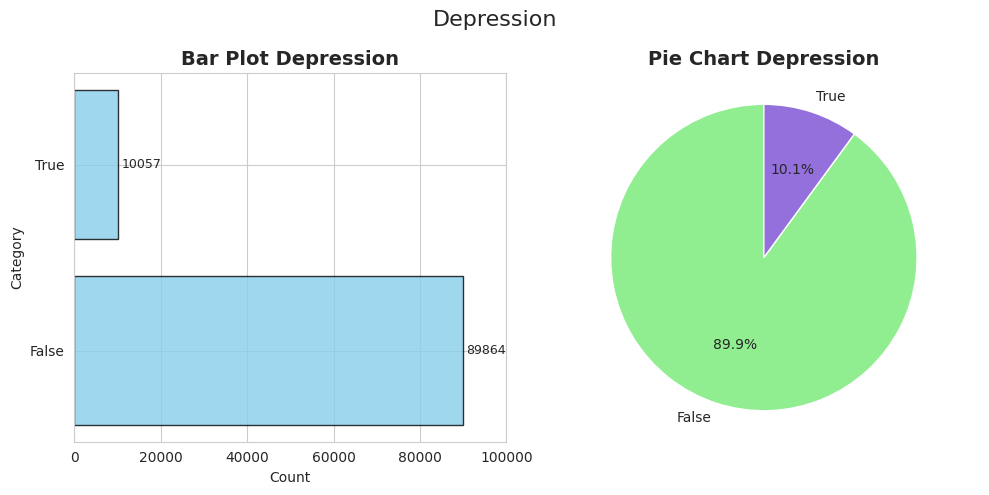

In [61]:
cat_columns = df.select_dtypes(include=['object', 'bool']).columns.tolist()

for col in cat_columns:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    sns.set_style("whitegrid")
    counted_data = df[col].value_counts()

    # bar plot
    bars = axes[0].barh(counted_data.index, counted_data.values,
                        color='skyblue', edgecolor='black', alpha=0.8)
    axes[0].set_title(f'Bar Plot {col}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Count')
    axes[0].set_ylabel('Category')

    for bar in bars:
       width = bar.get_width()
       axes[0].text(width + max(counted_data.values) * 0.01,
                     bar.get_y() + bar.get_height()/2,
                     f'{int(width)}',
                     va='center', fontsize=9)
    xlims = {
        'Gender': 50000,
        'Department': 30000,
        'Depression': 100000
    }
    axes[0].set_xlim(0, xlims[col])
    if col == 'Depression':
        axes[0].set_yticks([0, 1], ['False', 'True'])

    # pie chart
    axes[1].pie(counted_data.values, labels=counted_data.index,
           colors=['lightgreen', 'mediumpurple', 'pink', 'skyblue', 'hotpink'],
           autopct='%1.1f%%', startangle=90)
    axes[1].axis('equal')
    axes[1].set_title(f'Pie Chart {col}', fontsize=14, fontweight='bold')


    plt.suptitle(col, fontsize=16)
    plt.tight_layout()
    plt.show()

### Выводы из графиков
1) Видим, что в датасете нет пропусков.

2) Большинство признаков имеют либо нормальное, либо равномерное распределение, нет признаков с дисперсией, близкой к 0 (если бы были, то их вряд ли бы использовали для обучения).

3) В классе Depression есть дисбаланс , могут возникнуть проблемы с тем, что модель хорошо предсказывает только мажорный класс. Чтобы не допустить этого, будем сохранять одинаковое соотношение классов в обучающей и тестовой выборке, при обучении настроим веса классов (с помощью class_weight='balanced'), а также определим порог исходя из того, что нам важнее: найти всех, у кого точно есть депрессия, или найти всех, у кого есть подозрения на нее. Метрики будем оценивать исходя их этого.

4) Можем оценить содержание и количество выбросов/аномалий. В нашем случае это скорее именно аномалии, т.к. все ответы вполне реальные, просто редкие. Поскольку мы будем использовать именно линейные модели, которые очень чувствительны к аномальным значениям, нам нужно их обработать.

### Обработка выбросов и аномалий



In [62]:
stress_stats = df.groupby('Stress_Level').agg({
    'CGPA': 'mean',    # средняя успеваемость
    'Depression': 'mean'    # доля депрессий
}).round(3)

print(stress_stats)

               CGPA  Depression
Stress_Level                   
2             2.906       0.088
3             2.897       0.091
4             2.904       0.094
5             2.900       0.095
6             2.887       0.101
7             2.872       0.123
8             2.849       0.418
9             2.870       0.422
10            3.315       1.000


Для начала, обработаем аномалии в столбце Stress_Level. Уровень стресса точно влияет на дперессию, так что этот признак нам особо важен.
При этом у нас 484 ответа '9' и всего 4 ответа '10', что довольно странно. Для начала попытаемся понять, как уровень стресса влияет на таргеты:

Видим следующее:
- Успеваемость:

Она примерно одинаковая при уровне стресса от '2' до '9', а на '10' резко повышается. Для предсказывания успеваемости можем удалить строки со значением '10' в столбце Stress_Level. Их всего 4, поэтому мы почти не потеряем данных для обучения.


- Доля депрессии:

Она равномерно растет с уровнем стресса от '2' до '7' и резко повышается при '8'. При уровне стресса '10' депрессия оказывается у всех, но это может быть простым совпадением. Поэтому будем ориентироваться именно на скачок при уровне стресса на '8'. Я думаю, что хорошо будет создать бинарный признак High_Stress, равный 0 при уровне стресса <=7 и равный 1 при >=8, он хорошо отражает резкий скачок доли депрессий. Если мы одновременно будем использовать High_Stress и оставим Stress_Level, то получим мультиколлиниарные признаки, что испортит показания модели. Если мы удалим Stress_Level, то потеряем ещё 1 важный паттерн: при росте уровня стресса с 2 до 7 доля депрессий равномерно растет. Так что попытаемся сохранить оба паттерна: скачок на '8' и линейное возрастание депрессии на '2'-'7', при этом не делая их мультиколлинеарными. Сделаем так: для предсказания депрессии создадим новый бинарный признак High_Stress, а значения в Stress_Level, равные '8' и выше, заменим на '7', тогда на '7' будет как 0, так и 1 у High_Stress.

Оба паттерна сохранены, но мультиколлиниарности быть не должно.

Другие признаки с аномалиями: Sleep_Duration, Study_Hours и Social_Media_Hours. В них также нет некорректных значений, только очень редкие. Можно попробовать просто удалить их, т.к. суммарно это около 1500 строк, т.е. всего 1,5% датасета, что довольно мало. Пока оставим их, если показания модели будут плохими, то удалим и посмотрим, что изменилось.

### Корреляции
Сделаем heatmap на основе коэффициента Пирсона, демонстрирующий линейную корреляцию наших признаков:

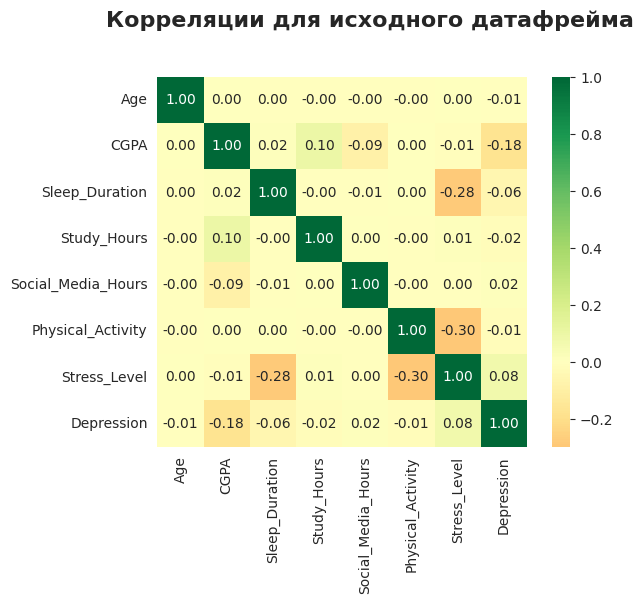

In [63]:
# heatmap
correlations = df.select_dtypes(include=[np.number, bool]).corr()
sns.heatmap(correlations, annot=True, cmap='RdYlGn', center=0, square=True, fmt='.2f')
plt.suptitle('Корреляции для исходного датафрейма', fontsize=16, fontweight='bold', y=1.02)
plt.show()

Во-первых, видим, что коллиниарных признаков нет.
Теперь рассмотрим, с чем коррелируют наши таргеты:

- Корреляция с CGPA: есть достаточно значимые коэффициенты с Study_Hours, Social_Media_Hours и Depression.
- Корреляция с Depression: достаточно большая у CGPA, Sleep_Duration и Stress_Level

Именно по коэффициенту корреляции мы выбрали не так уж много признаков, но исключать остальные тоже не стоит, т.к. даже если по отдельности признаки не дают большой коэффициент, их совместное действие может быть значительным.

### Feature-engineering
Мы уже добавили новые признаки, обрабатывая Stress_Level выше. Попробовали найти ещё что-нибудь, но пока ничего не поменяло метрики модели. Опробованные варианты:
- КПД студента - учеба/(соц.сети + сон). Получилась высокая корреляция с Study_Hours, а относительно таргета корреляция меньше. Показания модели не улучшались.
- Разные комбинации перемножений исходных признаков, которые в итоге не улучшили показания модели.

Поэтому остановимся на тех новых признаках, которые уже были добавлены при анализе уровня стресса.

Создадим 2 отдельных датафрейма для первой задачи (успеваемость) и для второй (депрессия) с новыми признаками, чтобы ниже сделать визуализации для них:

In [64]:
df_1 = df[df['Stress_Level'] <= 9].copy()
df_1.describe() # проверяем корректность изменений


,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,99917.000000,99917.000000,99917.000000,99917.000000,99917.000000,99917.000000,99917.000000
mean,21.008857,2.898229,6.994410,4.505713,3.501164,74.353644,4.131269
std,2.000398,0.532170,1.496842,1.972024,1.485030,43.363026,1.423694
min,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,9.000000


In [65]:
df_2 = df.copy()
df_2['Stress_Modified'] = df['Stress_Level'].clip(upper=7)
df_2['High_Stress'] = (df['Stress_Level'] >= 8).astype(int)
df_2 = df_2.drop(columns=['Stress_Level'])
df_2.describe() # проверяем корректность изменений

,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Modified,High_Stress
count,99921.000000,99921.000000,99921.000000,99921.000000,99921.000000,99921.000000,99921.000000,99921.000000
mean,21.008887,2.898246,6.994291,4.505956,3.501174,74.352458,4.106834,0.019846
std,2.000381,0.532189,1.496934,1.972359,1.485036,43.363229,1.360760,0.139471
min,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000,0.000000
25%,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000,0.000000
50%,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000,0.000000
75%,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000,0.000000
max,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,7.000000,1.000000


Сделаем визуализации для наших новых признаков (High_Stress и Stress_Modified):

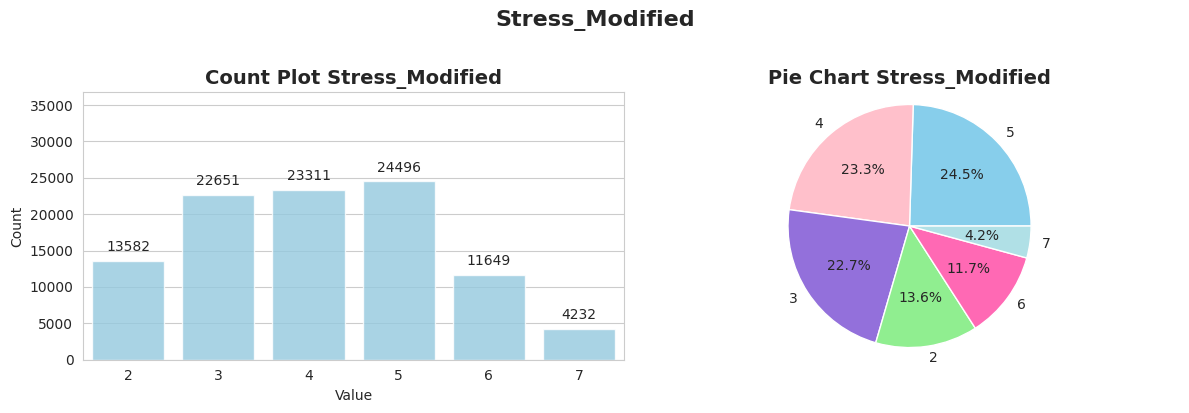

Stress_Modified:
  2: 13.5927 %
  3: 22.6689 %
  4: 23.3294 %
  5: 24.5154 %
  6: 11.6582 %
  7: 4.2353 %


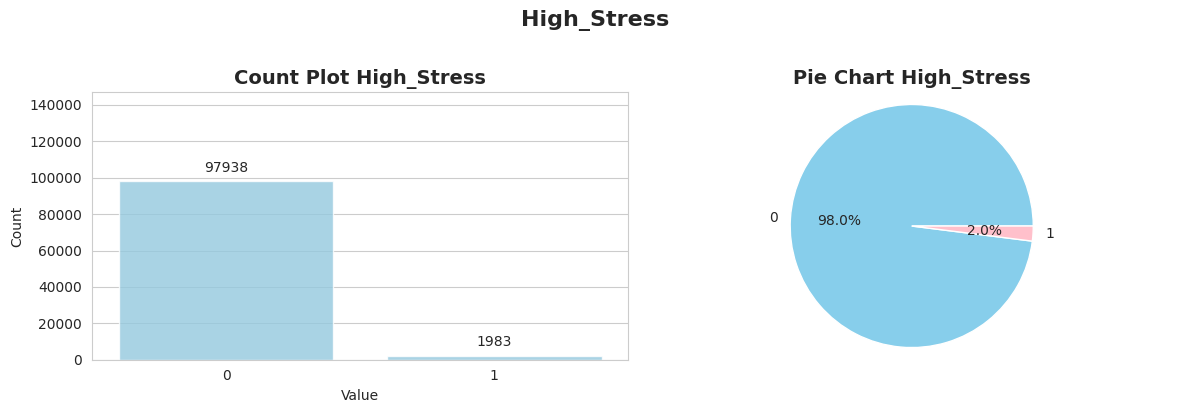

High_Stress:
  0: 98.0154 %
  1: 1.9846 %


In [66]:
for col in ('Stress_Modified', 'High_Stress'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.set_style("whitegrid")
    counted_data = df_2[col].value_counts()

    # count plot
    sns.countplot(data=df_2, x=col, ax=axes[0], color='skyblue', alpha=0.8)
    axes[0].set_title(f'Count Plot {col}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Count')
    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 10),
                    textcoords='offset points')
    axes[0].set_ylim(bottom=0, top=1.5*counted_data.values.max())

    # pie chart
    autopct = '%1.1f%%' if len(counted_data) <= 7 else None
    labels = counted_data.index if len(counted_data) <= 7 else None
    colors = ['skyblue', 'pink', 'mediumpurple', 'lightgreen', 'hotpink', 'powderblue', 'sandybrown', 'teal', 'plum']
    axes[1].pie(counted_data.values, labels=labels,
                colors=colors, autopct=autopct, startangle=0)
    axes[1].axis('equal')
    legend_data = [f'{name:3} - {(amount / counted_data.values.sum() * 100):1.2f} %' for name, amount in zip(counted_data.index, counted_data.values)]
    if not autopct:
        plt.legend(legend_data, bbox_to_anchor=(1, 0.9) , loc='best')
    axes[1].set_title(f'Pie Chart {col}', fontsize=14, fontweight='bold')

    plt.suptitle(col, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"{col}:")
    print(*sorted([f'{name:3}: {(amount / counted_data.values.sum() * 100):2.4f} %' for name, amount in zip(counted_data.index, counted_data.values)]), sep='\n')

Также сделаем Heatmap отдельно для первого и второго датафрейма с учетом изменений:

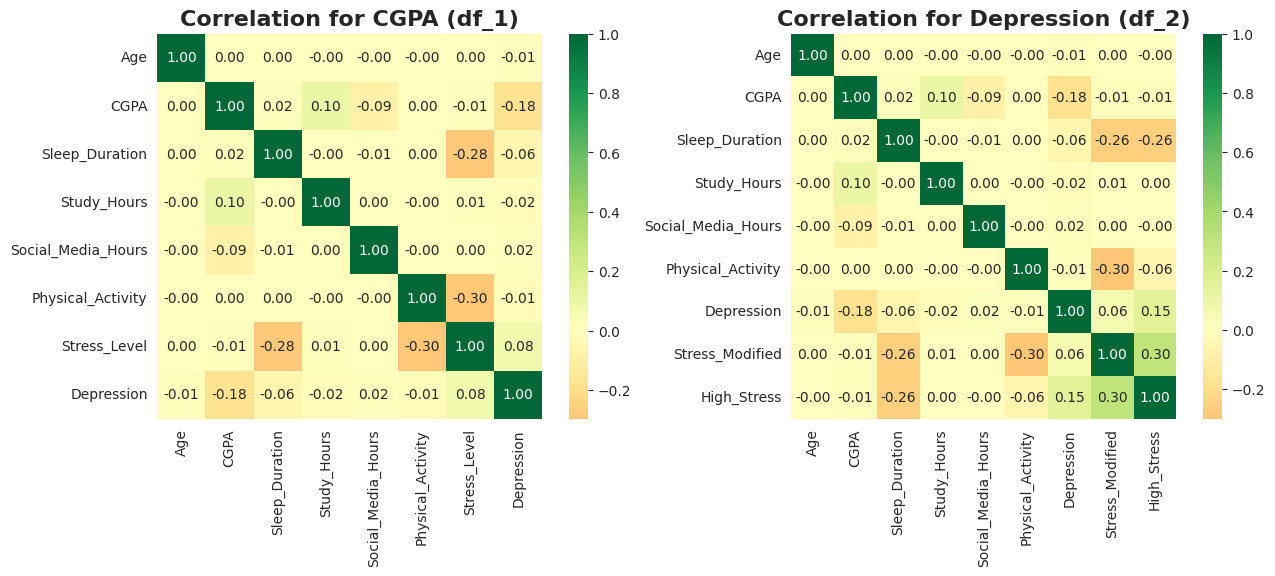

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

correlations_1 = df_1.select_dtypes(include=[np.number, bool]).corr()
sns.heatmap(correlations_1, ax=axes[0], annot=True, cmap='RdYlGn', center=0, square=True, fmt='.2f')
axes[0].set_title('Correlation for CGPA (df_1)', fontsize=16, fontweight='bold')

correlations_2 = df_2.select_dtypes(include=[np.number, bool]).corr()
sns.heatmap(correlations_2, ax=axes[1], annot=True, cmap='RdYlGn', center=0, square=True, fmt='.2f')
axes[1].set_title('Correlation for Depression (df_2)', fontsize=16, fontweight='bold')

plt.show()

Выводы:
- Для CGPA: Ничего особо не поменялось, после выкидывания аномальных значений уровня стресса признак Stress_Level не стал иметь больший коэффициент, а остальные признаки и не менялись.
- Для Depression: Наши новые признаки имеют неплохие коэффициенты Пирсона, можно их взять.

## Отобранные признаки
В итоге, методом анализа, были выделены следующие признаки для обучения:

**Задача линейной регрессии (CGPA):** Depression, Study_Hours, Sleep_Duration, Social_Media_Hours

**Задача логистической регрессии (Depression):** CGPA, Stress_Modified, High_Stress, Sleep_Duration, Study_Hours, Social_Media_Hours

In [75]:
df_1.drop(columns=['Age', 'Department', 'Physical_Activity', 'Stress_Level', 'Sleep_Duration'], inplace=True, errors='ignore')
df_2.drop(columns=['Age', 'Department', 'Physical_Activity'], inplace=True, errors='ignore')

### Кодирование категориальных признаков

In [77]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = df_1.select_dtypes(include=['object', 'category']).columns.tolist()
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_encoded_data = ohe.fit_transform(df_1[cat_cols])
ohe_df = pd.DataFrame(
    ohe_encoded_data,
    columns=ohe.get_feature_names_out(cat_cols),
    index=df_1.index
)

df_1 = df_1.drop(columns=cat_cols)
df_1 = pd.concat([df_1, ohe_df], axis=1)

cat_cols = df_2.select_dtypes(include=['object', 'category']).columns.tolist()
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_encoded_data = ohe.fit_transform(df_2[cat_cols])
ohe_df = pd.DataFrame(
    ohe_encoded_data,
    columns=ohe.get_feature_names_out(cat_cols),
    index=df_2.index
)

df_2 = df_2.drop(columns=cat_cols)
df_2 = pd.concat([df_2, ohe_df], axis=1)

df_2.head()

,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Depression,Stress_Modified,High_Stress,Gender_Female,Gender_Male
0,3.50,7.3,3.3,3.4,False,5,0,1.0,0.0
1,2.72,5.5,7.2,6.0,False,2,0,0.0,1.0
2,3.01,5.4,2.3,1.8,False,3,0,0.0,1.0
3,3.63,8.1,2.0,4.6,False,3,0,0.0,1.0
4,3.14,6.8,2.6,4.3,False,6,0,0.0,1.0


### Разделение данных и масштабирование
Разделим наши данные на обучающую и тестовую выборки и проведем масштабирование:

In [78]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1 задача (линейная регрессия)
y_1 = df_1['CGPA']
X_1 = df_1.drop(columns=['CGPA'])

# Делим на обучающую и тестовую выборки
X_1_train, X_1_test, y_1_train, y_1_test = train_test_split(
    X_1, y_1, test_size=0.2, random_state=42, shuffle=True  # соотношение 80/20
)
# масштабирование
scaler = StandardScaler()
X_1_train_scaled = scaler.fit_transform(X_1_train)
X_1_test_scaled = scaler.transform(X_1_test)

# 2 задача (логистическая регрессия)
# Все аналогично:
y_2 = df_2['Depression']
X_2 = df_2.drop(columns=['Depression'])

X_2_train, X_2_test, y_2_train, y_2_test = train_test_split(
    X_2, y_2, test_size=0.2, random_state=42, shuffle=True, stratify=y_2 # сохраняем соотношение классов на обучении и тесте
)

scaler = StandardScaler()
X_2_train_scaled = scaler.fit_transform(X_2_train)
X_2_test_scaled = scaler.transform(X_2_test)

Мы настроили скейлер именно на обучающих данных, поэтому данные теста не повлияли на них и утечки данных при масштабировании не произошло.

## Обучение модели
Обучим обе наши модели:

In [79]:
from sklearn.linear_model import LinearRegression, LogisticRegression

# CGPA
model_1 = LinearRegression()
model_1.fit(X_1_train_scaled, y_1_train)

y_1_train_pred = model_1.predict(X_1_train_scaled)
y_1_test_pred = model_1.predict(X_1_test_scaled)

# Депрессия
model_2 = LogisticRegression(class_weight='balanced')
model_2.fit(X_2_train_scaled, y_2_train)

y_2_train_pred = model_2.predict(X_2_train_scaled)
y_2_test_pred = model_2.predict(X_2_test_scaled)

LinearRegression() — создаёт объект модели линейной регрессии.
Модель ищет коэффициенты (веса) для формулы: CGPA = w₀ + w₁×X₁ + w₂×X₂ + ... + wₙ×Xₙ
Где:
w₀ — intercept (свободный член),
w₁...wₙ — коэффициенты для каждого признака,
X₁...Xₙ — масштабированные признаки

Модель минимизирует сумму квадратов ошибок (MSE):
Loss = Σ(y_true - y_pred)²

predict() — применяет обученную модель к данным:

На тренировочных данных — чтобы оценить качество на обучении

На тестовых данных — чтобы оценить качество на новых данных

Формула предсказания (после обучения):

y_pred = model_1.intercept_ + sum(model_1.coef_ * X)

LogisticRegression():
Логистическая регрессия предсказывает вероятность принадлежности к классу 1:

z = w₀ + w₁×X₁ + w₂×X₂ + ... + wₙ×Xₙ
p = 1 / (1 + e^(-z))   # sigmoid функция
Где:

z — линейная комбинация (от -∞ до +∞)

p — вероятность от 0 до 1

Если p >= 0.5 → класс 1, иначе класс 0

predict() возвращает классы (0 или 1), а не вероятности.

## Анализ результатов


Mean Absolute Error (MAE):  0.4460
Mean Squared Error (MSE):   0.2706
Root Mean Squared Error (RMSE): 0.5202
R-squared (R2):             0.0478

Проверка на переобучение:
RMSE на обучающей выборке:   0.5187
RMSE на тестовой выборке:    0.5202
Разница RMSE (Train - Test): -0.0015
R2 на обучающей выборке:     0.0490
R2 на тестовой выборке:      0.0478


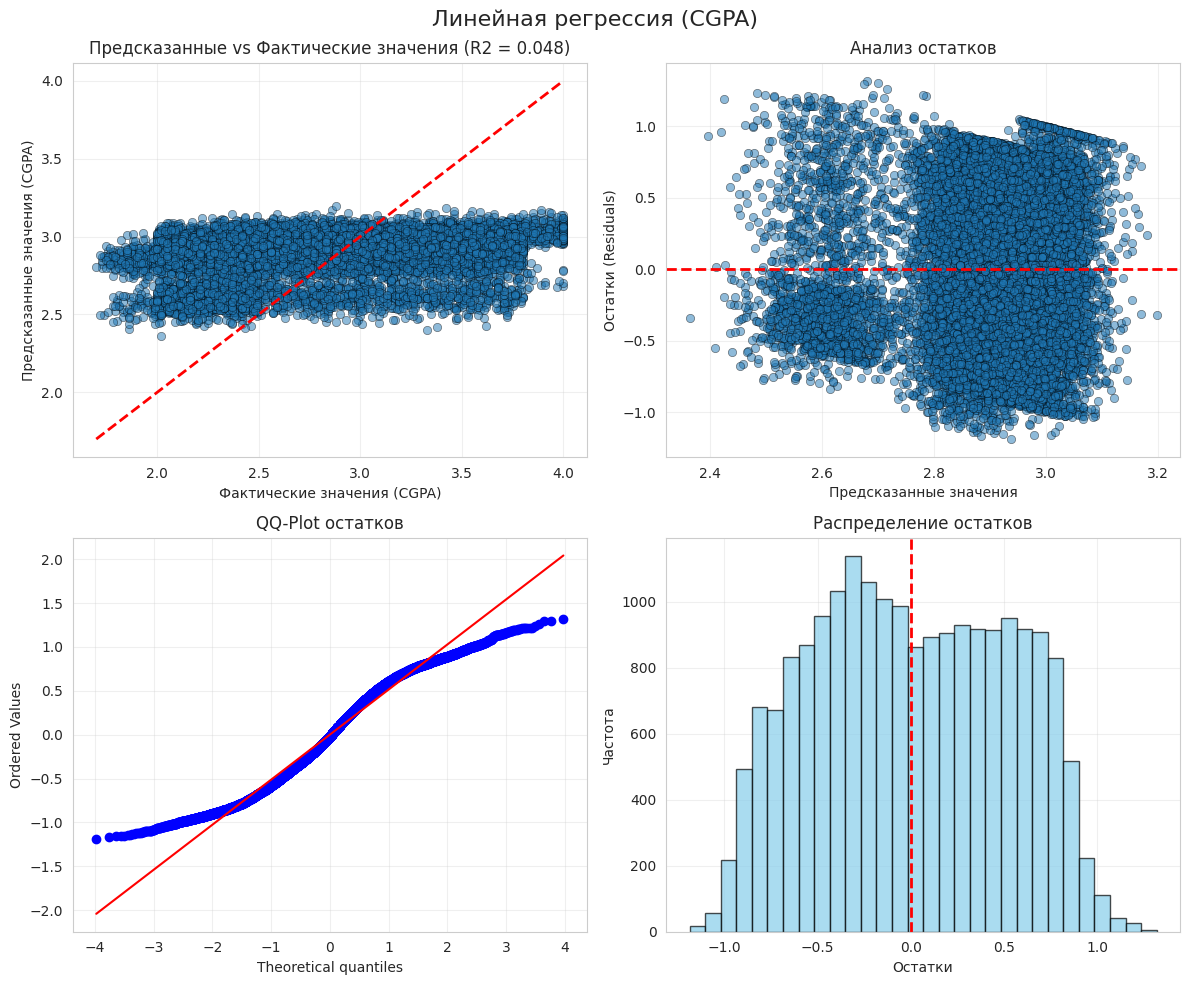

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

def evaluate_linear_regression(y_true, y_pred, model, X_train, X_test, y_train, y_test, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"Mean Absolute Error (MAE):  {mae:.4f}")
    print(f"Mean Squared Error (MSE):   {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R2):             {r2:.4f}")

    # проверка на переобучение (сравнение на train и test)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    print("\nПроверка на переобучение:")
    print(f"RMSE на обучающей выборке:   {train_rmse:.4f}")
    print(f"RMSE на тестовой выборке:    {test_rmse:.4f}")
    print(f"Разница RMSE (Train - Test): {train_rmse - test_rmse:.4f}")
    print(f"R2 на обучающей выборке:     {train_r2:.4f}")
    print(f"R2 на тестовой выборке:      {test_r2:.4f}")

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(model_name, fontsize=16)

    # предсказанные и фактические значения
    axes[0, 0].scatter(y_true, y_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
    axes[0, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    axes[0, 0].set_xlabel('Фактические значения (CGPA)')
    axes[0, 0].set_ylabel('Предсказанные значения (CGPA)')
    axes[0, 0].set_title(f'Предсказанные vs Фактические значения (R2 = {r2:.3f})')
    axes[0, 0].grid(True, alpha=0.3)

    # Остатки
    residuals = y_true - y_pred
    axes[0, 1].scatter(y_pred, residuals, alpha=0.5, edgecolors='k', linewidth=0.5)
    axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[0, 1].set_xlabel('Предсказанные значения')
    axes[0, 1].set_ylabel('Остатки (Residuals)')
    axes[0, 1].set_title('Анализ остатков')
    axes[0, 1].grid(True, alpha=0.3)

    # QQ-plot остатков (для проверки нормальности)
    stats.probplot(residuals, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title('QQ-Plot остатков')
    axes[1, 0].grid(True, alpha=0.3)

    # гистограмма остатков
    axes[1, 1].hist(residuals, bins=30, edgecolor='k', alpha=0.7, color='skyblue')
    axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
    axes[1, 1].set_xlabel('Остатки')
    axes[1, 1].set_ylabel('Частота')
    axes[1, 1].set_title('Распределение остатков')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

evaluate_linear_regression(
    y_true=y_1_test,
    y_pred=y_1_test_pred,
    model=model_1,
    X_train=X_1_train_scaled,
    X_test=X_1_test_scaled,
    y_train=y_1_train,
    y_test=y_1_test,
    model_name="Линейная регрессия (CGPA)"
)

Для линейной регрессии метрики получились не самыми лучшими. При подборе других метрик сильных изменений не наблюдалось. Возможно дело в том, что конкретно линейная регрессия плохо справляется с этой задачей, возможно проблема в том, что датасет мог быть сгенерирован.
Можно сказать, что переобучения не было.

Метрики модели логистической регрессии:

Accuracy:  0.6410
Precision: 0.1743
Recall:    0.6872
F1-Score:  0.2781
ROC-AUC:   0.6988

Проверка на переобучение:
Accuracy на обучающей выборке:   0.6409
Accuracy на тестовой выборке:    0.6410
Разница Accuracy (Train - Test): -0.0002
ROC-AUC на обучающей выборке:    0.6991
ROC-AUC на тестовой выборке:     0.6988


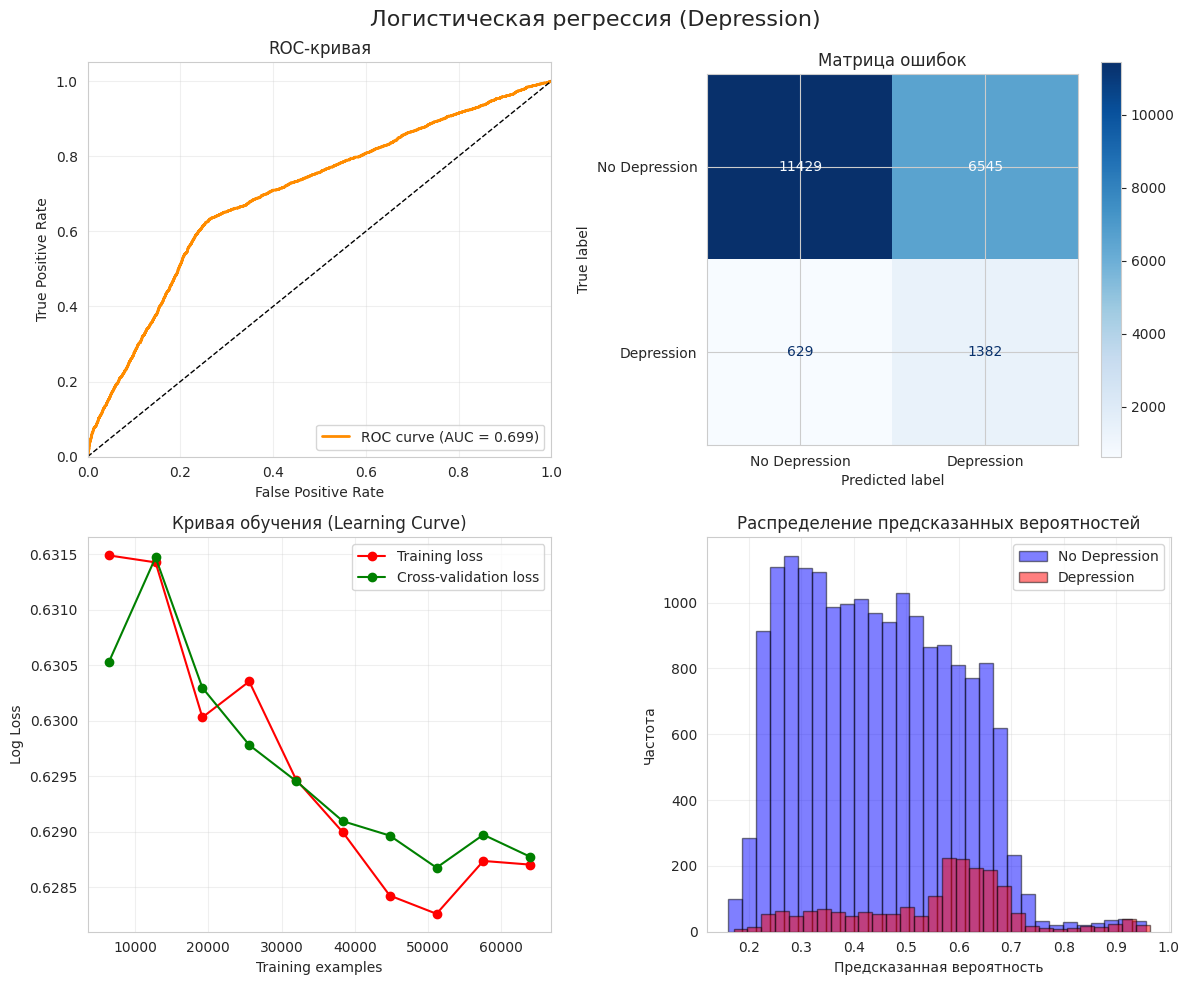

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve

def evaluate_logistic_regression(y_true, y_pred, y_pred_proba, model, X_train, y_train, X_test, y_test, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")

    # проверка на переобучение (сравнение на train и test)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    train_auc = roc_auc_score(y_train, train_proba)
    test_auc = roc_auc_score(y_test, test_proba)

    print("\nПроверка на переобучение:")
    print(f"Accuracy на обучающей выборке:   {train_acc:.4f}")
    print(f"Accuracy на тестовой выборке:    {test_acc:.4f}")
    print(f"Разница Accuracy (Train - Test): {train_acc - test_acc:.4f}")
    print(f"ROC-AUC на обучающей выборке:    {train_auc:.4f}")
    print(f"ROC-AUC на тестовой выборке:     {test_auc:.4f}")

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(model_name, fontsize=16)

    # ROC-кривая
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    axes[0, 0].plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})', color='darkorange', lw=2)
    axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0, 0].set_xlim([0.0, 1.0])
    axes[0, 0].set_ylim([0.0, 1.05])
    axes[0, 0].set_xlabel('False Positive Rate')
    axes[0, 0].set_ylabel('True Positive Rate')
    axes[0, 0].set_title('ROC-кривая')
    axes[0, 0].legend(loc="lower right")
    axes[0, 0].grid(True, alpha=0.3)

    # матрица ошибок
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Depression', 'Depression'])
    disp.plot(ax=axes[0, 1], cmap='Blues', values_format='d')
    axes[0, 1].set_title('Матрица ошибок')

    # кривая обучения(log loss)
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='neg_log_loss',
        shuffle=True, random_state=42
    )

    train_loss_mean = -np.mean(train_scores, axis=1)
    test_loss_mean = -np.mean(test_scores, axis=1)

    axes[1, 0].plot(train_sizes, train_loss_mean, 'o-', color='r', label='Training loss')
    axes[1, 0].plot(train_sizes, test_loss_mean, 'o-', color='g', label='Cross-validation loss')
    axes[1, 0].set_xlabel('Training examples')
    axes[1, 0].set_ylabel('Log Loss')
    axes[1, 0].set_title('Кривая обучения (Learning Curve)')
    axes[1, 0].legend(loc='best')
    axes[1, 0].grid(True, alpha=0.3)

    # распределение предсказанных вероятностей
    axes[1, 1].hist(y_pred_proba[y_true == 0], bins=30, alpha=0.5, label='No Depression', color='blue', edgecolor='black')
    axes[1, 1].hist(y_pred_proba[y_true == 1], bins=30, alpha=0.5, label='Depression', color='red', edgecolor='black')
    axes[1, 1].set_xlabel('Предсказанная вероятность')
    axes[1, 1].set_ylabel('Частота')
    axes[1, 1].set_title('Распределение предсказанных вероятностей')
    axes[1, 1].legend(loc='best')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

y_2_test_pred_proba = model_2.predict_proba(X_2_test_scaled)[:, 1]
evaluate_logistic_regression(
    y_true=y_2_test,
    y_pred=y_2_test_pred,
    y_pred_proba=y_2_test_pred_proba,
    model=model_2,
    X_train=X_2_train_scaled,
    y_train=y_2_train,
    X_test=X_2_test_scaled,
    y_test=y_2_test,
    model_name="Логистическая регрессия (Depression)"
)

Precision(точность) = TP/(TP + FP),
где:
TP (True Positives) — верно предсказанные положительные случаи;
FP (False Positives) — ложноположительные случаи (объекты, которые модель ошибочно классифицировала как положительные).
Recall(полнота) = TP/(TP + FN),
где:
FN (False Negatives) — ложноотрицательные случаи (объекты, которые модель не распознала как положительные, хотя они таковыми являются).


Метрики неидеальные, но уже явно лучше. Precision получилась низкой, зато Recall довольно высокий, что в данной задаче мне кажется важнее, т.к. мне было важнее найти всех людей с депрессией, чем точно поставить диагноз. ROC-AUC-кривая как минимум лучше, чем случайное угадывание.

Основной целью этой ЛР было освоить базовый пайплайн, так что метрики не так уж важны.